<a href="https://colab.research.google.com/github/LeonardVG/Reconhecimento-Facial-Rastreamento/blob/main/treinando_lbph_git.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Esse notebook é o pipeline para o treinamento do reconhecedor LBPH com dataset próprio (criado pelo script `criar.py`, que pode ser acessado [aqui](https://github.com/LeonardVG/Reconhecimento-Facial-Rastreamento/blob/main/criar.py).

⚠ **Importante:** Antes de executar o notebook, substitua os caminhos dos arquivos e do dataset utilizados no Google Colab pelos caminhos correspondentes ao seu ambiente de execução.


#importações

In [1]:
from PIL import Image
import numpy as np
import zipfile
import os
import time
from google.colab.patches import cv2_imshow
import cv2

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!pip uninstall -y opencv-python opencv-contrib-python opencv-python-headless opencv-contrib-python-headless


Found existing installation: opencv-python 4.13.0.92
Uninstalling opencv-python-4.13.0.92:
  Successfully uninstalled opencv-python-4.13.0.92
Found existing installation: opencv-contrib-python 4.13.0.92
Uninstalling opencv-contrib-python-4.13.0.92:
  Successfully uninstalled opencv-contrib-python-4.13.0.92
Found existing installation: opencv-python-headless 4.13.0.92
Uninstalling opencv-python-headless-4.13.0.92:
  Successfully uninstalled opencv-python-headless-4.13.0.92


In [4]:
!pip install opencv-contrib-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.2/79.2 MB 7.8 MB/s eta 0:00:00


##Importando datasets

In [2]:
path = '/content/drive/MyDrive/Colab Notebooks/Visao_Computacional/Curso-GuiaCompleto/Datasets/yalefaces.zip'
zip_object = zipfile.ZipFile(file=path, mode='r')
zip_object.extractall('./')
zip_object.close()

opicional, se tiver mais de um dataset

In [ ]:
path = '/content/drive/MyDrive/Colab Notebooks/SEU_OUTRO_DATASET.zip'
zip_object = zipfile.ZipFile(file=path, mode='r')
zip_object.extractall('./')
zip_object.close()

In [3]:
!mkdir -p /content/datasetTreino
!cp -r /content/yalefaces/train/* /content/datasetTreino
!cp -r /content/SEU_OUTRO_DATASET/* /content/datasetTreino

#Preprocessamento

In [7]:
def get_image_data():
  paths = [os.path.join('/content/datasetTreino', f) for f in os.listdir('/content/datasetTreino')]
  faces = []
  ids = []
  for path in paths:

    pessoa = os.path.split(path)[1].split('.')[0]
    if pessoa.startswith("face"):
      img = cv2.imread(path)
      img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
      img = cv2.resize(img,(320,243))
      img = np.array(img, 'uint8')
      id = int(0)
      ids.append(id)
      faces.append(img)

    else:
      imagem = Image.open(path).convert('L')
      imagem_np = np.array(imagem, 'uint8')
      id = int(1)
      ids.append(id)
      faces.append(imagem_np)

  return np.array(ids), faces

In [8]:
ids, faces = get_image_data()
print(f"total ids: {len(ids)}")
print(f"total faces: {len(faces)}")

total ids: 135
total faces: 135


In [9]:
t = np.unique(ids)  #O RESULTADO SERÁ 1 POIS PARA EXMPLIFICAR ESTOU UTILIZANDO APENAS DATASET DE OUTRAS PESSOAS,
t                   # QUANDO USAR SEU DATASET DEFINA TERÁ APENAS ids = 0

array([1])

Salvar faces e ids

In [10]:
np.save("faces.npy", faces)
np.save("ids.npy", ids)

In [11]:
ids

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1])

array([[130, 130, 130, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 230, 251, 248],
       [255, 255, 255, ..., 221, 225, 243],
       [ 68,  68,  68, ...,  68,  68,  68]], dtype=uint8)
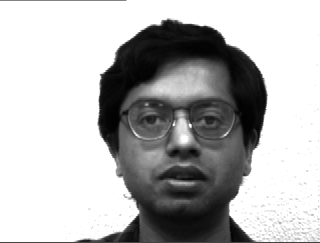

In [12]:
faces[0]

#Explorando dataset

In [14]:
caminhos = [os.path.join('/content/yalefaces', f) for f in os.listdir('/content/yalefaces')]
caminhos[:3]

['/content/yalefaces/train',
 '/content/yalefaces/.DS_Store',
 '/content/yalefaces/test']

In [16]:
img = cv2.imread(caminhos[0])
print(f"imagem do tipo: {type(img)}")


imagem do tipo: <class 'NoneType'>


In [ ]:
img[0][0][:]

array([110, 136, 150], dtype=uint8)

In [ ]:
#primeiro quebramos o caminho até o ponto:
#Exemplo em apenas uma imagem
path = caminhos[0]
img = cv2.imread(path)

print("caminho inteiro: " + path)
print("Usando Split, divide em 2 caminhos, retornando um vetor: " + str(os.path.split(path)))
print("primeira parte do caminho: " + os.path.split(path)[0])
print("segunda parte do caminho: " +os.path.split(path)[1])

print("separando a segunda parte pelo ponto: " + os.path.split(path)[1].split('.')[0])
person = os.path.split(path)[1].split('.')[0]
if person.startswith('f'):
  print("É o leonardo")
#print("usando replace para substituir o nome e ficar apenas com o número: " + os.path.split(path)[1].split('.')[0].replace('subject', ''))

caminho inteiro: /content/leoFaces/face64.jpeg
Usando Split, divide em 2 caminhos, retornando um vetor: ('/content/leoFaces', 'face64.jpeg')
primeira parte do caminho: /content/leoFaces
segunda parte do caminho: face64.jpeg
separando a segunda parte pelo ponto: face64
É o leonardo


In [ ]:
def get_image_data():
  paths = [os.path.join('/content/yalefaces/train', f) for f in os.listdir('/content/yalefaces/train')]
  faces = []
  ids = []
  for path in paths:
    imagem = Image.open(path).convert('L')
    imagem_np = np.array(imagem, 'uint8')

    id = int(os.path.split(path)[1].split('.')[0].replace('subject', ''))

    ids.append(id)
    faces.append(imagem_np)

  return np.array(ids), faces

#Treinamento

In [ ]:
lbph_classifier = cv2.face.LBPHFaceRecognizer_create()
lbph_classifier.train(faces, ids)
lbph_classifier.write('nome_que_voce_quiser_para_o_arquivo.yml')

#Reconhecimento

In [ ]:
lbph_classifier.read('/content/nome_que_voce_quiser_para_o_arquivo.yml')

#pegando uma imagem da pasta teste
#imagem_teste_path = '/content/datasetTreino/subject03.sad.gif' #outra pessoa -> classe 1
imagem_teste_path = '/content/datasetTreino/face64.jpeg' # deve ser classe 0

#imagem_teste_path = '/content/jones_gabriel/person.1.11.jpg'
pessoa = os.path.split(imagem_teste_path)[1].split('.')[0]
if pessoa.startswith('face'):
  img = cv2.imread(imagem_teste_path)
  img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  img = cv2.resize(img,(320,243))
  imagem_np = np.array(img, 'uint8')

else:
  imagem = Image.open(imagem_teste_path).convert('L')
  imagem_np = np.array(imagem, 'uint8')


#Detectando qual pessoa é
previsao = lbph_classifier.predict(imagem_np)
previsao

(0, 29.92403871800331)

In [ ]:
pessoa = os.path.split(imagem_teste_path)[1].split('.')[0]
if pessoa.startswith('face'):
  saida_esperada = int(0)
else:
  saida_esperada = int(-1)
print(f"Pessoa Esperada: Pessoa {saida_esperada}")

Pessoa Esperada: Pessoa 0


In [ ]:
def mostrar_img(imagem_np,previsao,saida_esperada):
  imagem_np = cv2.cvtColor(imagem_np, cv2.COLOR_GRAY2BGR)

  verde = (0,255,0)
  vermelho = (0,0,255)

  if previsao[0] == saida_esperada:
    cv2.putText(imagem_np, 'Pred: ' + str(previsao[0]), (10,30), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, verde)
    cv2.putText(imagem_np, 'Esperado: ' + str(saida_esperada), (10,50), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, verde)
  else:
    cv2.putText(imagem_np, 'Pred: ' + str(previsao[0]), (10,30), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, vermelho)
    cv2.putText(imagem_np, 'Esperado: ' + str(saida_esperada), (10,50), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, vermelho)


  cv2_imshow(imagem_np)

Descomente a célula seguinte

In [20]:
#mostrar_img(imagem_np,previsao,saida_esperada)

##testando


In [ ]:
path = '/content/drive/MyDrive/Colab Notebooks/seu_datasetTeste.zip'
zip_object = zipfile.ZipFile(file=path, mode='r')
zip_object.extractall('./')
zip_object.close()

In [ ]:
!cp -r /content/seu_datasetTeste/* /content/yalefaces/test

cp: target '/content/yalefaces/test' is not a directory


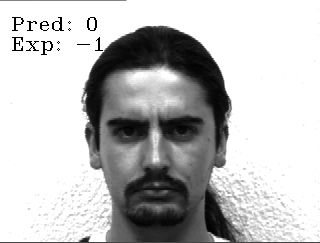

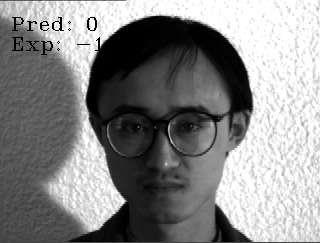

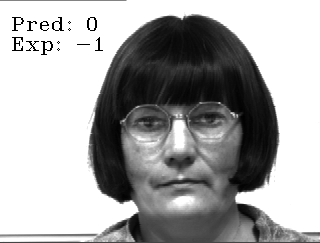

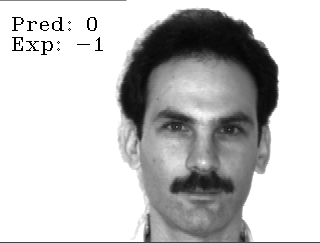

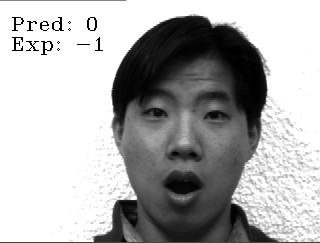

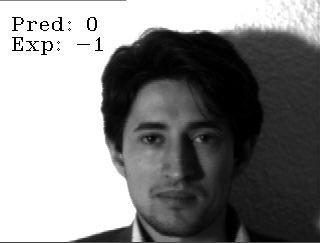

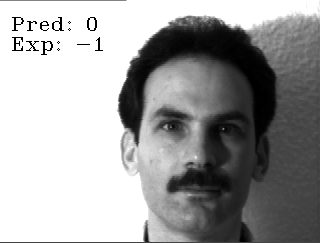

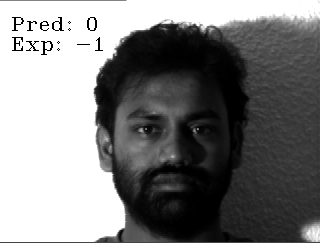

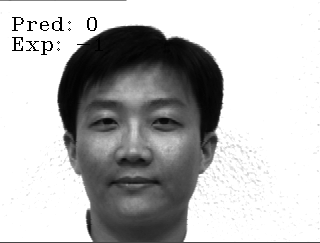

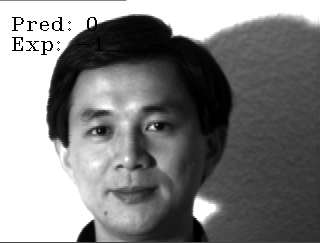

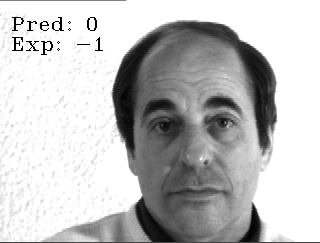

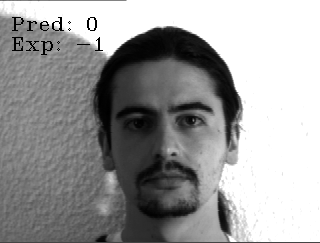

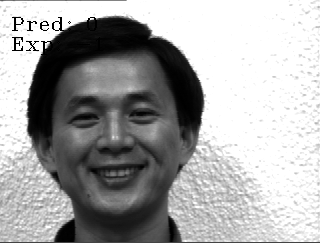

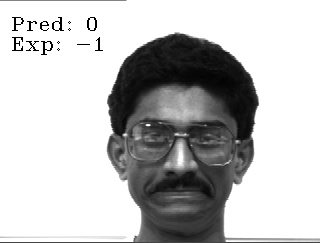

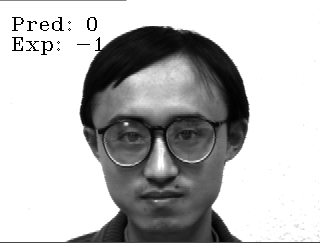

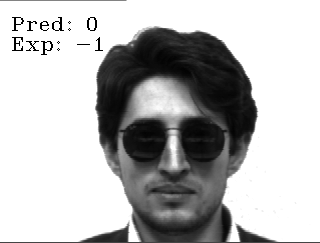

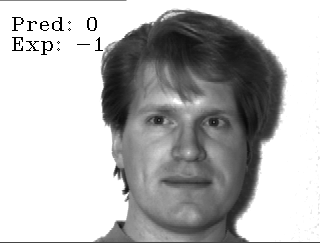

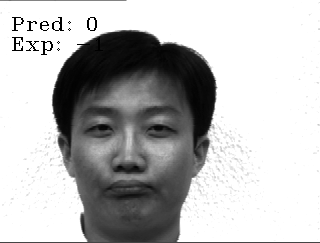

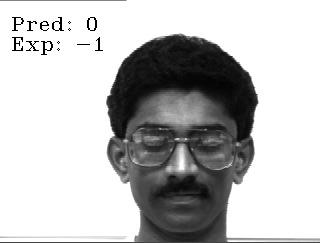

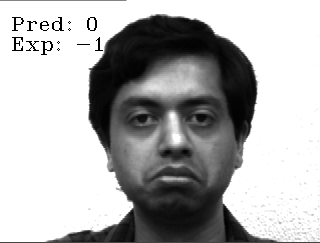

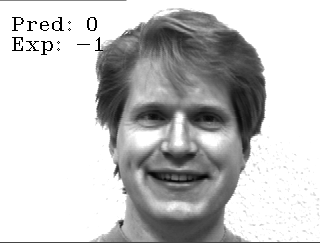

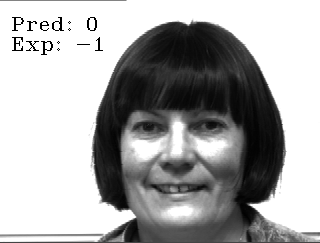

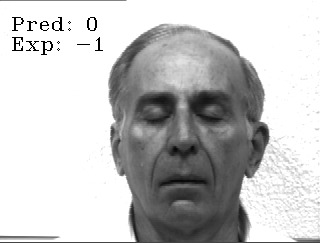

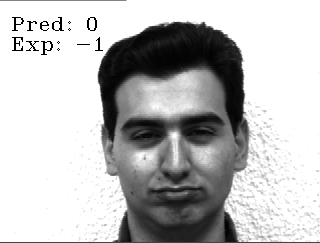

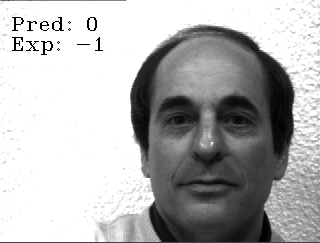

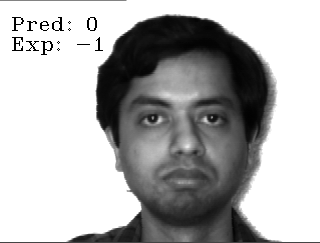

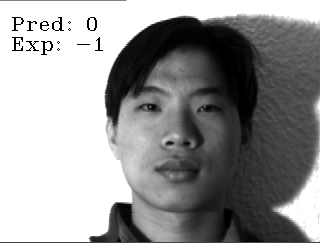

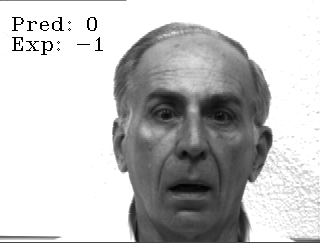

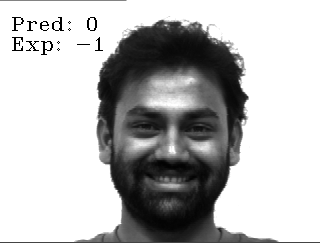

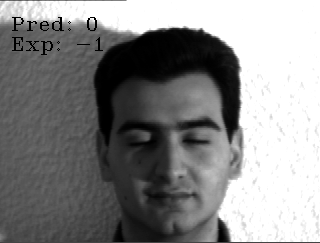

In [ ]:
#confianca = 0.1 #como treinamento é para apenas uma classe, o que importa é apenas a distância
previsoes = []
saidas_esperadas = []

paths = [os.path.join('/content/yalefaces/test', f) for f in os.listdir('/content/yalefaces/test')]
#Percorrendo cada imagem
for path in paths:
  pessoa = os.path.split(path)[1].split('.')[0]

  if pessoa.startswith('face'):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img,(320,243))
    imagem_np = np.array(img, 'uint8')

  else:
    imagem = Image.open(path).convert('L') #DLIB funciona com RGB, e assim podemos escrever colorido na imagem depois
    imagem_np = np.array(imagem, 'uint8')

  previsao = lbph_classifier.predict(imagem_np)

  nome_previsao = previsao[0]

  pessoa = os.path.split(path)[1].split('.')[0]
  if pessoa.startswith('face'):
   nome_real = 0
  else:
   nome_real = -1


  previsoes.append(nome_previsao)
  saidas_esperadas.append(nome_real)

  cv2.putText(imagem_np, 'Pred: ' + str(nome_previsao), (10,30), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, (0,255,0))
  cv2.putText(imagem_np, 'Exp: ' + str(nome_real), (10,50), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, (0,255,0))

  cv2_imshow(imagem_np)
#converter para depois poder fazer cálculos
previsoes = np.array(previsoes)
saidas_esperadas = np.array(saidas_esperadas)

##
* **Como o treinamento foi apenas com uma classe, esse teste não faz sentido, pois tudo é classificado com sendo da classe 0, porém o que comprova o reconhecimento é a distância**

* No entanto, esse código pode ser utilizado, assim como foi feito nesse [outro estudo](https://github.com/LeonardVG/cv-study-03-face-recognition-lbph).

In [ ]:
previsoes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
saidas_esperadas

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(saidas_esperadas,previsoes)

0.0